# 03 - Karp-Flatt analysis

Input:

- `analysis_output/preprocessed_core_data.csv`

Outputs:

- `analysis_output/karp_flatt_analysis.csv`
- `analysis_output/karp_flatt_metric.png`

Karp-Flatt metric:

\[
e = \frac{1/S_p - 1/p}{1 - 1/p}
\]

where:

- \(S_p\) is observed speedup
- \(p\) is the relative process count against the baseline

Interpretation:

- nearly constant \(e\): scaling is mostly limited by a fixed serial fraction
- increasing \(e\): overhead grows with process count
- near zero \(e\): near-ideal scaling


In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SOURCE = 'newest'
OUTPUT_DIR = Path("analysis_output")
INPUT_CSV = OUTPUT_DIR / f"preprocessed_data_{SOURCE}.csv"

df = pd.read_csv(INPUT_CSV)


In [19]:
agg = (
    df.groupby(["workers", "cores"], as_index=False)
    .agg(
        runs=("time_s", "size"),
        time_mean_s=("time_s", "mean"),
        bab_nodes_mean=("bab_nodes", "mean"),
    )
    .sort_values("cores")
    .reset_index(drop=True)
)

baseline = agg.iloc[0]
baseline_cores = baseline["cores"]
baseline_time = baseline["time_mean_s"]

agg["speedup"] = baseline_time / agg["time_mean_s"]
agg["relative_cores"] = agg["cores"] / baseline_cores

p = agg["relative_cores"].astype(float)
s = agg["speedup"].astype(float)

with np.errstate(divide="ignore", invalid="ignore"):
    agg["karp_flatt_e"] = ((1.0 / s) - (1.0 / p)) / (1.0 - (1.0 / p))

agg.loc[agg["relative_cores"] == 1.0, "karp_flatt_e"] = np.nan

valid = agg.dropna(subset=["karp_flatt_e"])
if len(valid) >= 2:
    slope = float(np.polyfit(valid["cores"], valid["karp_flatt_e"], deg=1)[0])
else:
    slope = np.nan

agg["karp_flatt_slope_vs_cores"] = slope

display(agg)


,workers,cores,runs,time_mean_s,bab_nodes_mean,speedup,relative_cores,karp_flatt_e,karp_flatt_slope_vs_cores
0,7,8,1,1234.405245,17757.0,1.000000,1.0,NaN,0.000027
1,15,16,1,592.235753,17811.0,2.084314,2.0,-0.040452,0.000027
2,63,64,1,147.406386,17761.0,8.374164,8.0,-0.006383,0.000027
3,127,128,1,75.849920,17729.0,16.274312,16.0,-0.001124,0.000027
4,255,256,1,46.394310,17813.0,26.606824,32.0,0.006539,0.000027
5,511,512,1,28.819229,17735.0,42.832695,64.0,0.007844,0.000027
6,1023,1024,1,16.589059,17829.0,74.410806,128.0,0.005671,0.000027


In [20]:
out = OUTPUT_DIR / f"karp_flatt_analysis_{SOURCE}.csv"
# agg.to_csv(out, index=False)
print(f"Saved: {out}")


Saved: analysis_output/karp_flatt_analysis_newest.csv


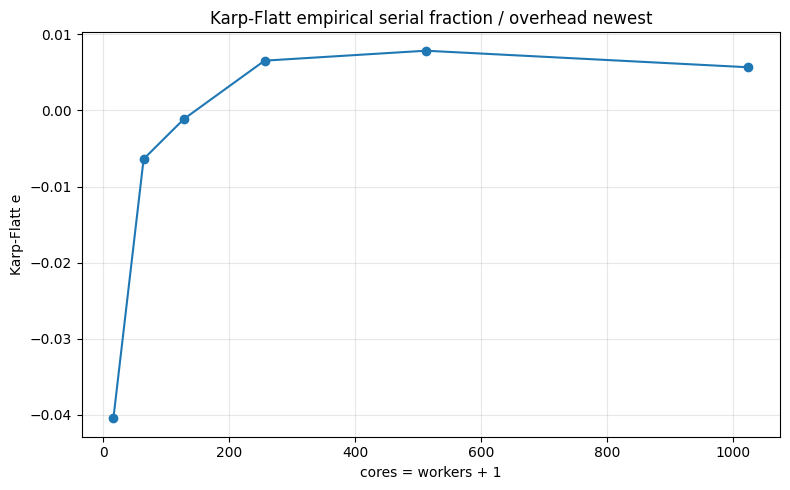

Saved: analysis_output/karp_flatt_metric_newest.png
Karp-Flatt trend: increasing. This suggests growing overhead or imbalance.


In [21]:
plt.figure(figsize=(8, 5))
plt.plot(agg["cores"], agg["karp_flatt_e"], marker="o")
plt.xlabel("cores = workers + 1")
plt.ylabel("Karp-Flatt e")
plt.title(f"Karp-Flatt empirical serial fraction / overhead {SOURCE}")
plt.grid(True, alpha=0.3)
plt.tight_layout()

out = OUTPUT_DIR / f"karp_flatt_metric_{SOURCE}.png"
plt.savefig(out, dpi=160)
plt.show()
print(f"Saved: {out}")

if np.isfinite(slope):
    if slope > 0:
        print("Karp-Flatt trend: increasing. This suggests growing overhead or imbalance.")
    elif slope < 0:
        print("Karp-Flatt trend: decreasing. This can happen from noise, cache effects, or changed search work.")
    else:
        print("Karp-Flatt trend: flat.")
else:
    print("Not enough Karp-Flatt points to compute a trend.")
